In [20]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

def generate_graph(n=1000, p=0.005):
    """
    Generate a fixed random graph (Erdős-Rényi model)
    """
    G = nx.erdos_renyi_graph(n, p, directed=True)
    return G

def generate_scale_free_graph(n=1000, m=3):
    """
    Generate a scale-free graph (Barabási-Albert model)
    """
    G = nx.barabasi_albert_graph(n, m)
    G = G.to_directed()
    return G

def power_iteration(G, alpha=0.85, max_iter=100, tol=1e-8):
    """
    using the power iteration method to compute the stationary distribution pi_m 
    """
    N = G.number_of_nodes()
    # 获取转移矩阵 P
    P = nx.google_matrix(G, alpha=alpha)
    
    # 初始分布向量
    pi = np.ones(N) / N
    for i in range(max_iter):
        pi_next = np.dot(pi, P)
        if np.linalg.norm(pi_next - pi, ord=1) < tol:
            break
        pi = pi_next
    return np.array(pi).flatten()

def random_walk_simulation(G, alpha=0.85, steps=10**5):
    """
    Simulate random walks to obtain frequency distributions pi_s 
    """
    N = G.number_of_nodes()
    nodes = list(G.nodes())
    counts = np.zeros(N)
    
    current_node = np.random.choice(nodes)
    
    for _ in range(steps):
        counts[current_node] += 1
        # 以 alpha 概率沿着链接走，以 1-alpha 概率随机跳转
        if np.random.rand() < alpha and list(G.successors(current_node)):
            current_node = np.random.choice(list(G.successors(current_node)))
        else:
            current_node = np.random.choice(nodes)
            
    return counts / steps

def get_ranking(pi):
    """
    Ranking based on score vectors sigma
    """
    # 返回的是索引，按得分从大到小排列
    return np.argsort(-pi)

def get_top_k_kendall_tau(pi_theory, pi_sim, k=20):
    """
    Kendall Tau similarity is calculated only for the top k nodes in the theoretical ranking.
    """

    top_k_indices = np.argsort(-pi_theory)[:k]

    ranks_theory = pi_theory[top_k_indices]
    ranks_sim = pi_sim[top_k_indices]
    
    tau, _ = kendalltau(ranks_theory, ranks_sim)
    return tau

In [21]:

# 1. initialization
N = 1000
G = generate_scale_free_graph(N)

# 2. Power Iteration
pi_m = power_iteration(G)
sigma_m = get_ranking(pi_m)

print(f"理论排名前5位: {sigma_m[:5]}")

# 3. Random Walk Simulation and Evaluation
steps_list = [10**3, 10**4, 10**5, 10**6, 10**7]
results_global = {}
results_20 = {}

for s in steps_list:
    pi_s = random_walk_simulation(G, steps=s)
    
    # compute global Kendall Tau
    global_tau, _ = kendalltau(np.argsort(-pi_m), np.argsort(-pi_s))
    results_global[s] = global_tau
    
    # compute top 20 Kendall Tau
    top_20_tau = get_top_k_kendall_tau(pi_m, pi_s, k=20)
    results_20[s] = top_20_tau
    
    print(f"步数 10^{int(np.log10(s))}:")
    print(f"  - 全局 Kendall Tau: {global_tau:.4f}")
    print(f"  - 前 20 名 Kendall Tau: {top_20_tau:.4f}")

理论排名前5位: [4 8 5 0 1]
步数 10^3:
  - 全局 Kendall Tau: 0.1505
  - 前 20 名 Kendall Tau: 0.5655
步数 10^4:
  - 全局 Kendall Tau: 0.2840
  - 前 20 名 Kendall Tau: 0.8042
步数 10^5:
  - 全局 Kendall Tau: 0.3278
  - 前 20 名 Kendall Tau: 0.8947
步数 10^6:
  - 全局 Kendall Tau: 0.4414
  - 前 20 名 Kendall Tau: 0.9263
步数 10^7:
  - 全局 Kendall Tau: 0.4994
  - 前 20 名 Kendall Tau: 1.0000


In [22]:
results_g=[]
results_20_list=[]
for s in steps_list:
    results_g.append(results_global[s])
    results_20_list.append(results_20[s])

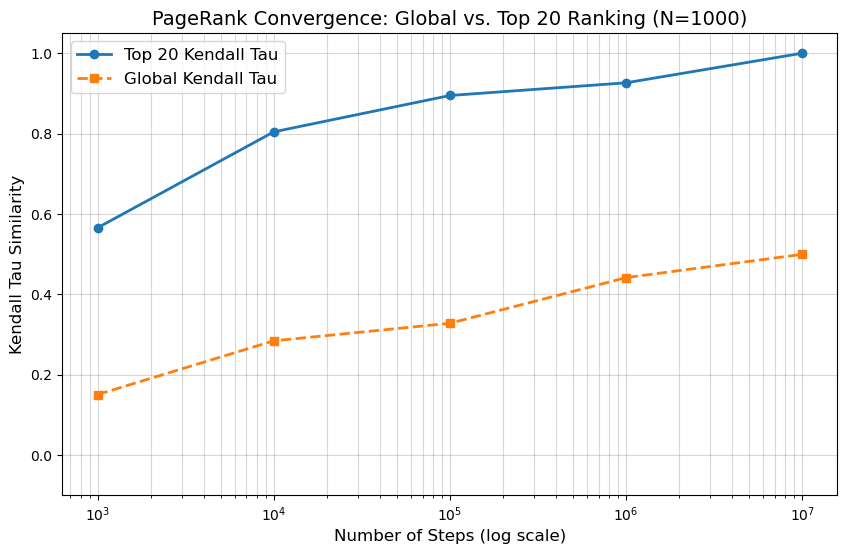

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(steps_list, results_20_list, marker='o', linestyle='-', linewidth=2, label='Top 20 Kendall Tau')
plt.plot(steps_list, results_g, marker='s', linestyle='--', linewidth=2, label='Global Kendall Tau')

plt.xscale('log')

plt.title('PageRank Convergence: Global vs. Top 20 Ranking (N=1000)', fontsize=14)
plt.xlabel('Number of Steps (log scale)', fontsize=12)
plt.ylabel('Kendall Tau Similarity', fontsize=12)

plt.ylim(-0.1, 1.05)

plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(fontsize=12)

plt.show()

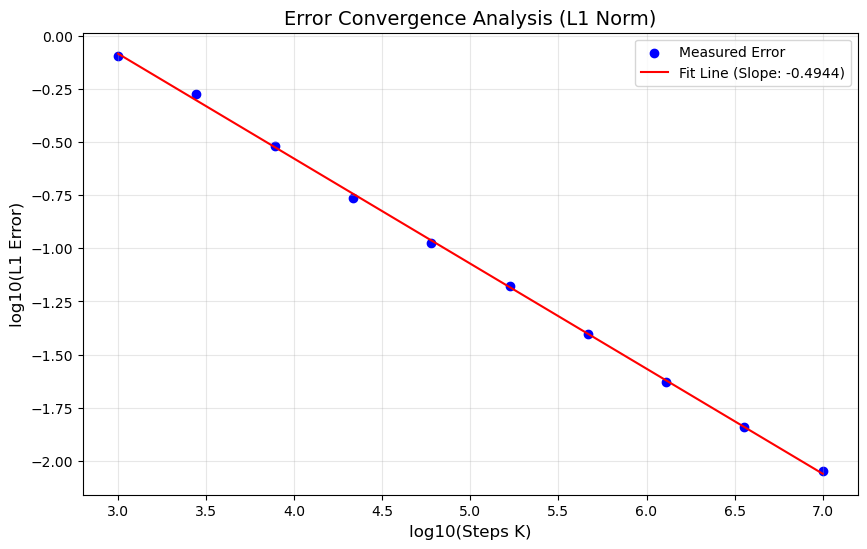

回归斜率 (Slope): -0.4944
判定系数 (R-squared): 0.9995


In [24]:
from scipy.stats import linregress
# 1. prepare different magnitudes of steps K
ks = np.logspace(3, 7, 10).astype(int)
errors = []

# 2. compute errors for each K
for k in ks:
    # 运行模拟得到频率分布
    pi_s = random_walk_simulation(G, steps=k)
    
    l1_error = np.sum(np.abs(pi_s - pi_m))
    errors.append(l1_error)

# 3. perform linear regression on log-log data
log_k = np.log10(ks)
log_error = np.log10(errors)
slope, intercept, r_value, p_value, std_err = linregress(log_k, log_error)

# 4. plot
plt.figure(figsize=(10, 6))
plt.scatter(log_k, log_error, color='blue', label='Measured Error')
plt.plot(log_k, slope * log_k + intercept, color='red', 
         label=f'Fit Line (Slope: {slope:.4f})')

plt.title('Error Convergence Analysis (L1 Norm)', fontsize=14)
plt.xlabel('log10(Steps K)', fontsize=12)
plt.ylabel('log10(L1 Error)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"回归斜率 (Slope): {slope:.4f}")
print(f"判定系数 (R-squared): {r_value**2:.4f}")

In [25]:
import networkx as nx
#1. Load the arXiv citation data from the provided file path
def load_arxiv_data(file_path):
    G = nx.read_edgelist(file_path, create_using=nx.DiGraph(), nodetype=int)
    print(f"节点数: {G.number_of_nodes()}, 边数: {G.number_of_edges()}")
    return G

G = load_arxiv_data('/mnt/data1/zhutianchi/homework/QH/Cit-HepTh.txt')
# 假设 G 是你加载的 DiGraph 对象
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print(f"当前图节点数: {num_nodes} (官方预期: 27,770)")
print(f"当前图边数: {num_edges} (官方预期: 352,807)")

# 验证连通性
is_directed = G.is_directed()
print(f"是否为有向图: {is_directed} (官方预期: True)")

节点数: 27770, 边数: 352807
当前图节点数: 27770 (官方预期: 27,770)
当前图边数: 352807 (官方预期: 352,807)
是否为有向图: True (官方预期: True)


In [26]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import cupy as cp
from scipy.stats import kendalltau
from tqdm import tqdm

In [27]:
def load_and_preprocess_arxiv(file_path):
    print(f"正在加载数据集: {file_path}...")
    G = nx.read_edgelist(file_path, create_using=nx.DiGraph(), nodetype=int, comments='#')
    
    all_node_ids = sorted(list(G.nodes()))
    node_to_idx = {node_id: i for i, node_id in enumerate(all_node_ids)}
    idx_to_node = {i: node_id for i, node_id in enumerate(all_node_ids)}
    num_nodes = len(all_node_ids)
    
    print(f"节点数: {num_nodes}, 边数: {G.number_of_edges()}")
    return G, node_to_idx, idx_to_node, all_node_ids

# 2. compute theoretical PageRank using Power Iteration (CPU sparse matrix)
def get_theoretical_pagerank(G, alpha=0.85):
    print("正在计算理论平稳分布 (Power Iteration)...")
    pr_dict = nx.pagerank(G, alpha=alpha)
    pi_m = np.array([pr_dict[node] for node in sorted(G.nodes())])
    return pi_m

# 3. simulate random walks on GPU
def random_walk_gpu(G, node_to_idx, all_node_ids, steps, alpha=0.85):
    N = len(all_node_ids)
    all_nodes_gpu = cp.array(all_node_ids)
    counts_gpu = cp.zeros(N, dtype=cp.float32)
    
    adj = {u: list(G.successors(u)) for u in G.nodes()}
    
    curr_node = int(np.random.choice(all_node_ids))
    
    print(f"开始 GPU 模拟步数: 10^{int(np.log10(steps))}")
    
    batch_size = 100000
    for i in range(0, steps, batch_size):
        current_batch = min(batch_size, steps - i)
        rand_vals = cp.random.random(current_batch)
        teleport_nodes = cp.random.choice(all_nodes_gpu, current_batch)
        
        for j in range(current_batch):
            counts_gpu[node_to_idx[curr_node]] += 1
            
            neighbors = adj[curr_node]
            if rand_vals[j] < alpha and neighbors:
                curr_node = int(np.random.choice(neighbors))
            else:
                curr_node = int(teleport_nodes[j])
                
    return cp.asnumpy(counts_gpu / steps)

# 4. compute Kendall Tau similarity for top k nodes
def get_top_k_kendall(pi_m, pi_s, k=20):
    top_k_idx = np.argsort(-pi_m)[:k]
    tau, _ = kendalltau(pi_m[top_k_idx], pi_s[top_k_idx])
    return tau

In [28]:
def random_walk_gpu_with_progress(G, node_to_idx, all_node_ids, steps=10**7, alpha=0.85):

    N = len(all_node_ids)
    all_nodes_gpu = cp.array(all_node_ids)
    counts_gpu = cp.zeros(N, dtype=cp.float32)
    
    adj = {u: list(G.successors(u)) for u in G.nodes()}
    curr_node = int(np.random.choice(all_node_ids))
    
    batch_size = 100000 
    num_batches = steps // batch_size
    remainder = steps % batch_size

    print(f"start simulation {steps} steps")
    
    with tqdm(total=steps, desc="Random Walk Simulation", unit="step") as pbar:
        # 处理整批数据
        for _ in range(num_batches):
            rand_vals = cp.random.random(batch_size)
            teleport_nodes = cp.random.choice(all_nodes_gpu, batch_size)

            for j in range(batch_size):
                counts_gpu[node_to_idx[curr_node]] += 1
                neighbors = adj[curr_node]
                
                if rand_vals[j] < alpha and neighbors:
                    curr_node = int(np.random.choice(neighbors))
                else:
                    curr_node = int(teleport_nodes[j])
            
            pbar.update(batch_size)
            
        if remainder > 0:
            rand_vals = cp.random.random(remainder)
            teleport_nodes = cp.random.choice(all_nodes_gpu, remainder)
            for j in range(remainder):
                counts_gpu[node_to_idx[curr_node]] += 1
                neighbors = adj[curr_node]
                if rand_vals[j] < alpha and neighbors:
                    curr_node = int(np.random.choice(neighbors))
                else:
                    curr_node = int(teleport_nodes[j])
            pbar.update(remainder)

    return cp.asnumpy(counts_gpu / steps)

In [29]:
import numpy as np
import networkx as nx
import scipy.sparse as sp
from numba import njit
from tqdm import tqdm
from scipy.stats import kendalltau
import matplotlib.pyplot as plt

In [30]:
@njit
def _numba_random_walk(indices, indptr, n_nodes, steps, alpha):
    counts = np.zeros(n_nodes, dtype=np.int64)
    curr_node = np.random.randint(0, n_nodes)
    
    for _ in range(steps):
        counts[curr_node] += 1
        
        start = indptr[curr_node]
        end = indptr[curr_node + 1]
        
        if np.random.random() < alpha and start < end:
            choice_idx = np.random.randint(start, end)
            curr_node = indices[choice_idx]
        else:
            curr_node = np.random.randint(0, n_nodes)
            
    return counts

In [31]:
def fast_pagerank_simulation(G, steps=10**7, alpha=0.85):
    nodes = sorted(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    n_nodes = len(nodes)
    
    adj_matrix = nx.to_scipy_sparse_array(G, nodelist=nodes, weight=None)
    csr = adj_matrix.tocsr()
    
    print(f"start simulation {steps} steps (Numba JIT accelerated)...")
    batch_size = steps // 100
    total_counts = np.zeros(n_nodes, dtype=np.int64)
    
    with tqdm(total=steps, desc="Simulation Progress") as pbar:
        for _ in range(100):
            batch_counts = _numba_random_walk(csr.indices, csr.indptr, n_nodes, batch_size, alpha)
            total_counts += batch_counts
            pbar.update(batch_size)
            
    return total_counts / steps, nodes

In [32]:
print("loading dataset...")
G = nx.read_edgelist('Cit-HepTh.txt', create_using=nx.DiGraph(), nodetype=int, comments='#')

# 计算理论值
print("calculating theoretical PageRank (NetworkX)...")
pr_theoretical_dict = nx.pagerank(G, alpha=0.85)
nodes_sorted = sorted(G.nodes())
pi_m = np.array([pr_theoretical_dict[n] for n in nodes_sorted])

# 运行优化后的模拟
steps_list = [10**4, 10**5, 10**6, 10**7, 10**8]
results_20 = []
results_global = []

for steps in steps_list:
    pi_s, nodes = fast_pagerank_simulation(G, steps=steps)

    top_20_idx = np.argsort(-pi_m)[:20]
    tau_20, _ = kendalltau(pi_m[top_20_idx], pi_s[top_20_idx])

    tau_global, _ = kendalltau(np.argsort(-pi_m), np.argsort(-pi_s))
    results_20.append(tau_20)
    results_global.append(tau_global)
    print("\n--- result ---")
    print(f"simulation steps: 10^{int(np.log10(steps))}")
    print(f"Top 20 Kendall Tau: {tau_20:.4f}")
    print(f"Global Kendall Tau: {tau_global:.4f}")

    print("\ntheoretical Top 5:", [nodes[i] for i in np.argsort(-pi_m)[:5]])
    print("simulated ranking Top 5:", [nodes[i] for i in np.argsort(-pi_s)[:5]])

loading dataset...
calculating theoretical PageRank (NetworkX)...
start simulation 10000 steps (Numba JIT accelerated)...


Simulation Progress: 100%|██████████| 10000/10000 [00:00<00:00, 55059.26it/s]


--- result ---
simulation steps: 10^4
Top 20 Kendall Tau: 0.5474
Global Kendall Tau: -0.0384

theoretical Top 5: [9407087, 9503124, 9510017, 9402044, 9711200]
simulated ranking Top 5: [9503124, 9407087, 9510017, 9402002, 9408099]


start simulation 100000 steps (Numba JIT accelerated)...


Simulation Progress: 100%|██████████| 100000/100000 [00:00<00:00, 10546136.63it/s]

...

start simulation 10000000 steps (Numba JIT accelerated)...


Simulation Progress: 100%|██████████| 10000000/10000000 [00:00<00:00, 21662152.75it/s]



--- result ---
simulation steps: 10^7
Top 20 Kendall Tau: 0.7895
Global Kendall Tau: 0.0318

theoretical Top 5: [9407087, 9503124, 9510017, 9402044, 9711200]
simulated ranking Top 5: [9207016, 9407087, 9201015, 9503124, 9510017]
start simulation 100000000 steps (Numba JIT accelerated)...


Simulation Progress: 100%|██████████| 100000000/100000000 [00:04<00:00, 22080240.64it/s]


--- result ---
simulation steps: 10^8
Top 20 Kendall Tau: 0.7895
Global Kendall Tau: 0.0277

theoretical Top 5: [9407087, 9503124, 9510017, 9402044, 9711200]
simulated ranking Top 5: [9207016, 9407087, 9201015, 9503124, 9510017]


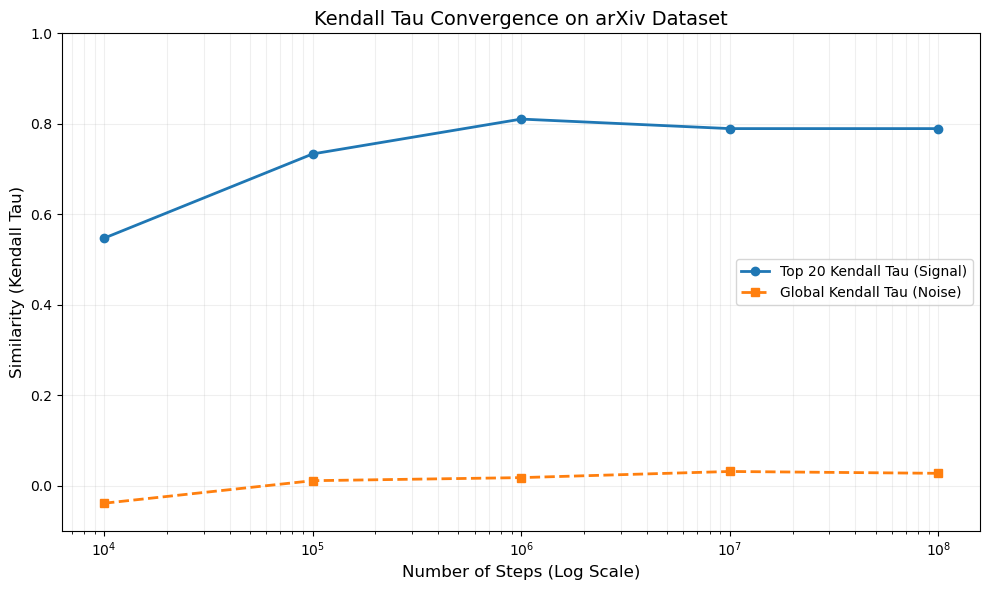

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(steps_list, results_20, marker='o', linewidth=2, label='Top 20 Kendall Tau (Signal)')
plt.plot(steps_list, results_global, marker='s', linestyle='--', linewidth=2, label='Global Kendall Tau (Noise)')

plt.xscale('log')
plt.ylim(-0.1, 1.0)
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.title('Kendall Tau Convergence on arXiv Dataset', fontsize=14)
plt.xlabel('Number of Steps (Log Scale)', fontsize=12)
plt.ylabel('Similarity (Kendall Tau)', fontsize=12)
plt.legend(loc='center right')

plt.tight_layout()
plt.show()